# Recent Machine Learning Trends

Machine learning is evolving rapidly. Modern ML is no longer limited to
training a model on a fixed dataset and evaluating it once.

Recent developments emphasize:

- foundation models
- transformers
- generative AI
- multimodal learning
- retrieval-augmented generation
- parameter-efficient fine-tuning
- self-supervised learning
- synthetic data
- trustworthy AI
- efficient machine learning
- continual learning
- agentic systems
- edge and small models

This notebook studies the major ideas behind these developments from a
machine learning and computer science perspective.

The objective is not simply to use modern tools, but to understand the
technical concepts that make these systems possible.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
Pandas: 3.0.5


## 1. From Traditional ML to Modern ML

Traditional machine learning commonly follows this pipeline:

$$
\text{Data}
\rightarrow
\text{Feature Engineering}
\rightarrow
\text{Model Training}
\rightarrow
\text{Prediction}
$$

Modern machine learning increasingly follows a broader pipeline:

$$
\text{Large-Scale Data}
\rightarrow
\text{Pretraining}
\rightarrow
\text{Adaptation}
\rightarrow
\text{Retrieval / Tools}
\rightarrow
\text{Inference}
\rightarrow
\text{Continuous Evaluation}
$$

Several important shifts have occurred.

### Shift 1 — Feature engineering → Representation learning

Instead of manually designing all useful features, neural networks can
learn representations directly from raw data.

### Shift 2 — Task-specific models → Foundation models

A single pretrained model can be adapted to many downstream tasks.

### Shift 3 — Supervised learning → Self-supervised learning

Large quantities of unlabeled data can be used to construct training
objectives without requiring manually labeled examples.

### Shift 4 — Prediction → Generation

Modern models can generate:

- text
- images
- audio
- video
- code
- structured outputs

### Shift 5 — Static models → Systems

Modern ML applications increasingly combine models with:

- databases
- retrieval systems
- external tools
- memory
- APIs
- monitoring
- evaluation pipelines

## 2. Foundation Models

A foundation model is a model trained on broad data at large scale and
then adapted to many downstream applications.

A simplified formulation is:

$$
\theta^*
=
\arg\min_{\theta}
\mathcal{L}_{pretrain}(\theta; D)
$$

where:

- $D$ is a large pretraining dataset
- $\theta$ represents model parameters
- $\mathcal{L}_{pretrain}$ is the pretraining objective

After pretraining, the learned parameters can be adapted:

$$
\theta_{adapted}
=
\operatorname{Adapt}(\theta^*, D_{task})
$$

This creates a separation between:

1. **Pretraining**
2. **Adaptation**
3. **Inference**

This is one of the most important conceptual changes in modern ML.

### Why Foundation Models Matter

A traditional model might solve:

$$
x \rightarrow y_{specific}
$$

A foundation model attempts to learn a much more general representation:

$$
x \rightarrow z
$$

where $z$ captures useful structure that can later support many tasks.

The same pretrained representation can potentially support:

- classification
- summarization
- question answering
- translation
- code generation
- reasoning
- information extraction

## 3. Transformers and Attention

The Transformer architecture introduced a highly scalable approach to
sequence modeling based primarily on attention mechanisms.

The fundamental operation is scaled dot-product attention.

Given query, key, and value matrices:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

attention is computed as:

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$

where $d_k$ is the dimensionality of the key vectors.

The matrix

$$
\frac{QK^T}{\sqrt{d_k}}
$$

contains pairwise compatibility scores between tokens.

In [2]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]

    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V

    return output, weights


np.random.seed(42)

Q = np.random.randn(5, 8)
K = np.random.randn(5, 8)
V = np.random.randn(5, 8)

attention_output, attention_weights = scaled_dot_product_attention(
    Q, K, V
)

print("Attention output shape:", attention_output.shape)
print("Attention weights shape:", attention_weights.shape)

Attention output shape: (5, 8)
Attention weights shape: (5, 5)


### Interpretation

Each row of the attention matrix represents a query position.

The values indicate how strongly that position attends to every key
position.

The weights satisfy:

$$
\sum_j A_{ij} = 1
$$

for every query position $i$.

This allows a token representation to incorporate information from
other positions in the sequence.

## 4. Generative AI

Generative models attempt to learn the underlying distribution of data
and generate new samples.

A generative model can be viewed as learning:

$$
p(x)
$$

or, in conditional generation:

$$
p(x \mid c)
$$

where $c$ represents conditioning information.

Examples include:

- language generation
- image generation
- audio generation
- video generation
- code generation

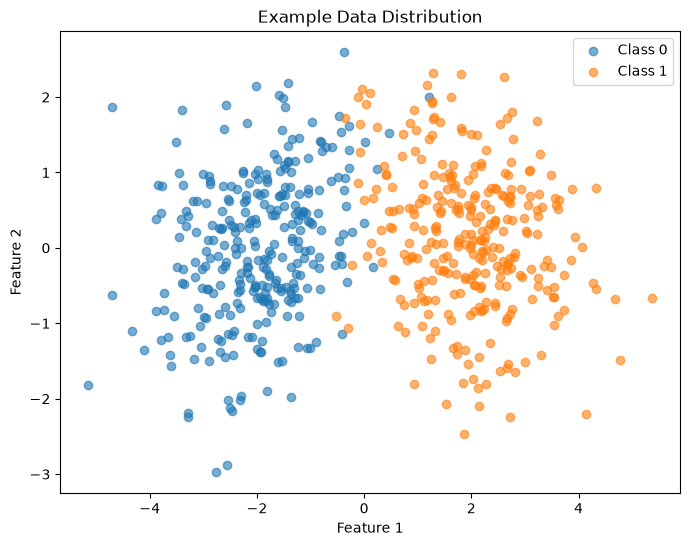

In [3]:
np.random.seed(42)

class_0 = np.random.multivariate_normal(
    mean=[-2, 0],
    cov=[[1, 0.3], [0.3, 1]],
    size=300
)

class_1 = np.random.multivariate_normal(
    mean=[2, 0],
    cov=[[1, -0.3], [-0.3, 1]],
    size=300
)

plt.figure(figsize=(8, 6))

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    alpha=0.6,
    label="Class 0"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    alpha=0.6,
    label="Class 1"
)

plt.title("Example Data Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

A discriminative model focuses on:

$$
p(y \mid x)
$$

while a generative model can model:

$$
p(x)
$$

or:

$$
p(x,y)
$$

This distinction becomes important when understanding modern generative
models.

## 5. Diffusion Models

Diffusion models generate data by learning to reverse a gradual
corruption process.

During the forward process, noise is progressively added:

$$
x_0
\rightarrow
x_1
\rightarrow
\cdots
\rightarrow
x_T
$$

Eventually the sample approaches a noise distribution.

The model then learns the reverse process:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

A simplified forward process can be expressed as:

$$
q(x_t \mid x_{t-1})
=
\mathcal{N}
\left(
x_t;
\sqrt{1-\beta_t}x_{t-1},
\beta_t I
\right)
$$

where $\beta_t$ controls the amount of noise added at timestep $t$.

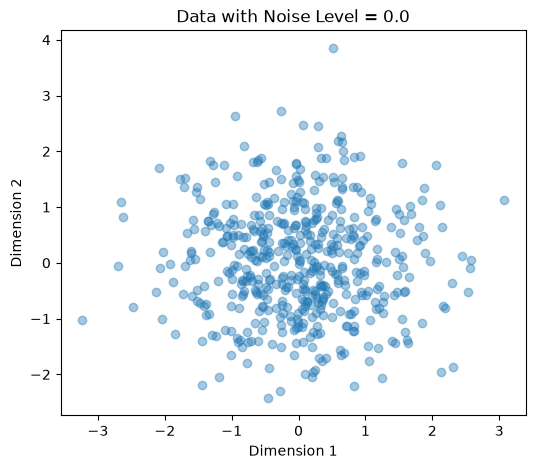

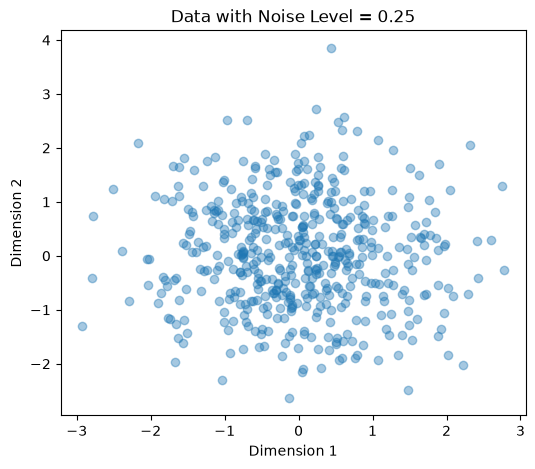

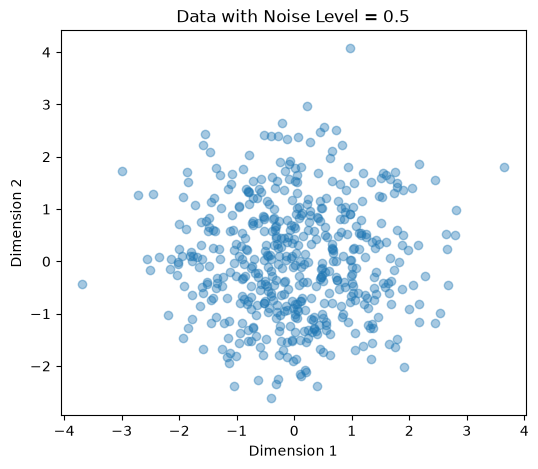

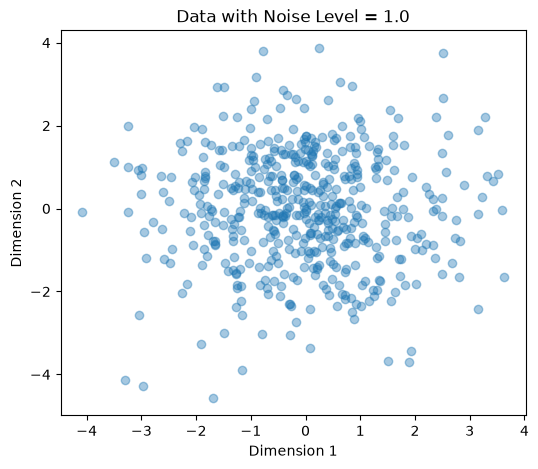

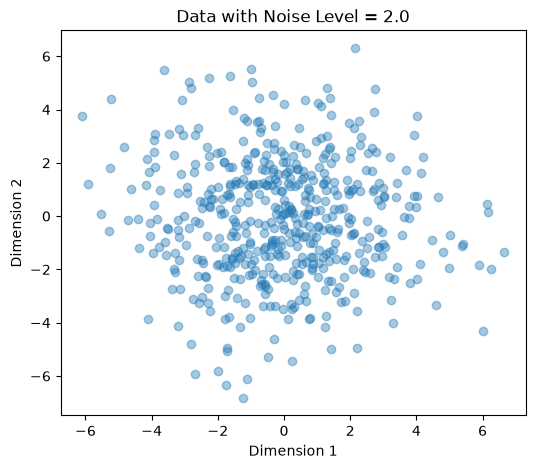

In [4]:
np.random.seed(42)

x = np.random.randn(500, 2)

noise_levels = [0.0, 0.25, 0.5, 1.0, 2.0]

for noise in noise_levels:
    noisy_x = x + noise * np.random.randn(*x.shape)

    plt.figure(figsize=(6, 5))

    plt.scatter(
        noisy_x[:, 0],
        noisy_x[:, 1],
        alpha=0.4
    )

    plt.title(f"Data with Noise Level = {noise}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

## 6. Retrieval-Augmented Generation (RAG)

A major modern trend is combining a generative model with an external
knowledge source.

Instead of relying entirely on parameters learned during training:

$$
\text{Question}
\rightarrow
\text{Model}
\rightarrow
\text{Answer}
$$

RAG introduces retrieval:

$$
\text{Question}
\rightarrow
\text{Retriever}
\rightarrow
\text{Relevant Context}
\rightarrow
\text{Generator}
\rightarrow
\text{Answer}
$$

A simplified pipeline is:

1. Convert the query into an embedding.
2. Search a vector database.
3. Retrieve relevant documents.
4. Insert the documents into the model context.
5. Generate an answer.

The central idea is to separate:

**Knowledge storage** from **language generation**.

In [5]:
documents = [
    "Machine learning learns patterns from data.",
    "Deep learning uses neural networks with multiple layers.",
    "Transformers use attention mechanisms.",
    "Reinforcement learning learns through interaction and rewards.",
    "Federated learning trains models across decentralized devices."
]

query = "How do transformers work?"

def word_overlap_score(query, document):
    query_words = set(query.lower().split())
    document_words = set(document.lower().split())

    return len(query_words & document_words)


scores = [
    word_overlap_score(query, doc)
    for doc in documents
]

retrieved_idx = np.argsort(scores)[::-1]

for idx in retrieved_idx[:3]:
    print(documents[idx])

Transformers use attention mechanisms.
Federated learning trains models across decentralized devices.
Reinforcement learning learns through interaction and rewards.


This example is intentionally simple.

Production RAG systems normally use semantic embeddings rather than
simple word overlap.

A semantic retriever approximates:

$$
s(q,d)
=
\operatorname{similarity}
\left(
f(q), f(d)
\right)
$$

where $f(\cdot)$ maps queries and documents into an embedding space.

## 7. Parameter-Efficient Fine-Tuning

Full fine-tuning updates all model parameters.

If a model contains $N$ parameters, full fine-tuning requires updating
approximately:

$$
N
$$

parameters.

Parameter-efficient fine-tuning instead keeps most parameters frozen
and learns a much smaller set of additional parameters.

This dramatically reduces:

- memory requirements
- training cost
- storage requirements
- adaptation time

## 8. Low-Rank Adaptation (LoRA)

LoRA approximates a parameter update using low-rank matrices.

Instead of directly learning:

$$
\Delta W
$$

LoRA represents the update as:

$$
\Delta W = BA
$$

where:

$$
B \in \mathbb{R}^{d \times r}
$$

and

$$
A \in \mathbb{R}^{r \times k}
$$

with:

$$
r \ll \min(d,k)
$$

The adapted weight becomes:

$$
W' = W + BA
$$

The key idea is that the adaptation can occupy a much lower-dimensional
subspace than the original parameter matrix.

In [6]:
d = 1024
k = 1024
r = 8

full_parameters = d * k
lora_parameters = d * r + r * k

reduction = 1 - (lora_parameters / full_parameters)

print("Full parameters:", full_parameters)
print("LoRA parameters:", lora_parameters)
print("Parameter reduction:", f"{reduction:.2%}")

Full parameters: 1048576
LoRA parameters: 16384
Parameter reduction: 98.44%


## 9. Self-Supervised Learning

Self-supervised learning creates training targets from the data itself.

Instead of requiring:

$$
(x,y)
$$

the system constructs a learning problem from $x$.

For example, language modeling can predict a missing or next token:

$$
P(x_t \mid x_1,\ldots,x_{t-1})
$$

The loss can be written as:

$$
\mathcal{L}
=
-\sum_t
\log P_\theta
\left(
x_t
\mid
x_{<t}
\right)
$$

This allows models to learn from enormous collections of unlabeled
data.

## 10. Multimodal Machine Learning

Modern systems increasingly operate across multiple modalities:

- text
- images
- audio
- video
- structured data

A multimodal system attempts to learn relationships between different
representations.

For example:

$$
f_{text}(x_{text})
\approx
f_{image}(x_{image})
$$

when both describe the same semantic concept.

A shared embedding space can allow cross-modal retrieval:

$$
\operatorname{similarity}
(
z_{text},
z_{image}
)
$$

This enables applications such as:

- image search using text
- image captioning
- visual question answering
- document understanding
- audio-text search

## 11. Synthetic Data

Synthetic data is artificially generated data designed to supplement
or replace some real training data.

A simplified pipeline is:

$$
D_{real}
\rightarrow
\text{Generative Model}
\rightarrow
D_{synthetic}
\rightarrow
D_{train}
$$

Synthetic data can help with:

- rare classes
- privacy-sensitive datasets
- simulation
- data augmentation
- expensive labeling processes

However, synthetic data can also amplify model errors.

If:

$$
P_{synthetic}(x)
\neq
P_{real}(x)
$$

then training primarily on synthetic data may introduce distribution
shift.

## 12. Continual Learning

Traditional ML often assumes a fixed training distribution.

Continual learning considers:

$$
D_1 \rightarrow D_2 \rightarrow D_3 \rightarrow \cdots
$$

where the data distribution changes over time.

The challenge is **catastrophic forgetting**.

A model trained on task $B$ may lose performance on task $A$:

$$
Performance_A(\theta_B)
<
Performance_A(\theta_A)
$$

Modern ML systems therefore increasingly require mechanisms for:

- adaptation
- replay
- regularization
- memory
- distribution-shift detection

## 13. Federated Learning

Federated learning allows multiple clients to collaboratively train a
model without directly centralizing their raw training data.

A simplified formulation is:

$$
\theta_{t+1}
=
\sum_{k=1}^{K}
\frac{n_k}{n}
\theta_{t+1}^{(k)}
$$

where:

- $K$ is the number of clients
- $n_k$ is the amount of data at client $k$
- $n$ is the total amount of training data

The central idea is:

$$
\text{Data stays local}
$$

while:

$$
\text{Model updates are aggregated}
$$

## 14. Explainable, Trustworthy and Responsible AI

Modern ML systems are increasingly evaluated not only by predictive
performance but also by properties such as:

- robustness
- fairness
- interpretability
- privacy
- reliability
- calibration
- security

A useful conceptual objective is therefore:

$$
\text{ML Quality}
=
f(
\text{Accuracy},
\text{Robustness},
\text{Fairness},
\text{Reliability},
\text{Efficiency}
)
$$

This represents a major shift from optimizing a single metric toward
evaluating the entire ML system.

## 15. Efficient and Green Machine Learning

Large models can require substantial computational resources.

Important research directions include:

- quantization
- pruning
- knowledge distillation
- sparsity
- efficient architectures
- hardware-aware optimization

For example, quantization reduces numerical precision:

$$
FP32
\rightarrow
FP16
\rightarrow
INT8
$$

Lower precision can reduce memory usage and improve inference
efficiency, depending on hardware and workload.

## 16. Agentic Machine Learning Systems

A newer direction is moving from models that simply generate an answer
toward systems that can perform multi-step actions.

A simplified architecture is:

$$
\text{Goal}
\rightarrow
\text{Planning}
\rightarrow
\text{Tool Use}
\rightarrow
\text{Observation}
\rightarrow
\text{Reasoning}
\rightarrow
\text{Action}
$$

An agent may interact with:

- search systems
- databases
- APIs
- code execution environments
- external tools
- memory systems

The important distinction is:

**Model**

versus

**Model + Environment + Tools + Feedback Loop**

## 17. Small Models and Edge AI

Not every application requires the largest possible model.

Smaller models can be valuable when:

- latency is important
- privacy is important
- computation is limited
- internet connectivity is unreliable
- inference must occur on-device

The optimization problem becomes:

$$
\max_{\theta}
\quad
\text{Task Performance}
$$

subject to:

$$
Memory \leq M
$$

$$
Latency \leq L
$$

$$
Energy \leq E
$$

This makes hardware-aware ML an increasingly important area.

## 18. Modern Machine Learning System

A modern ML application can be represented as:

$$
\boxed{
\text{Data}
\rightarrow
\text{Pretraining}
\rightarrow
\text{Foundation Model}
\rightarrow
\text{Adaptation}
\rightarrow
\text{Retrieval}
\rightarrow
\text{Tools}
\rightarrow
\text{Inference}
\rightarrow
\text{Evaluation}
}
$$

The system is surrounded by additional concerns:

- monitoring
- security
- privacy
- governance
- cost
- latency

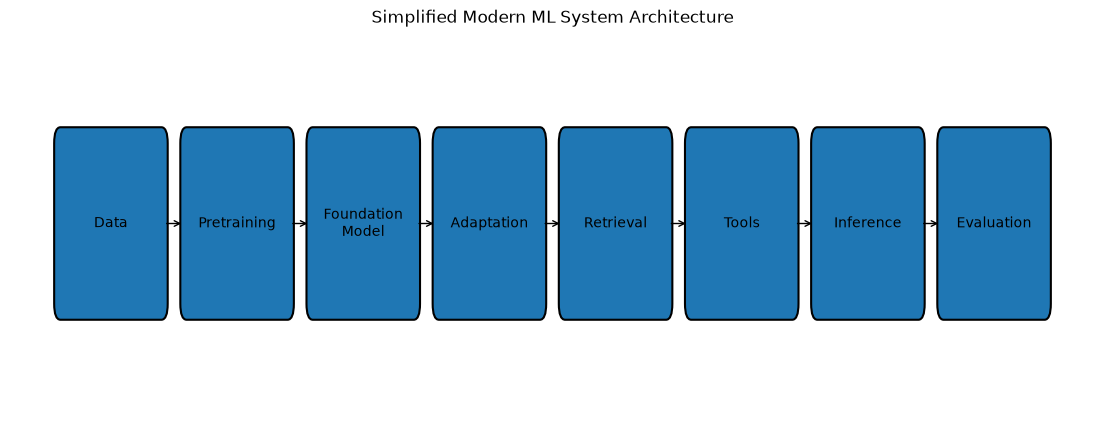

In [7]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 5))

steps = [
    "Data",
    "Pretraining",
    "Foundation\nModel",
    "Adaptation",
    "Retrieval",
    "Tools",
    "Inference",
    "Evaluation"
]

x_positions = np.arange(len(steps))

for x, step in zip(x_positions, steps):
    box = FancyBboxPatch(
        (x - 0.4, 0.35),
        0.8,
        0.5,
        boxstyle="round,pad=0.05",
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        x,
        0.6,
        step,
        ha="center",
        va="center",
        fontsize=10
    )

    if x < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + 0.58, 0.6),
            xytext=(x + 0.42, 0.6),
            arrowprops=dict(arrowstyle="->")
        )

ax.set_xlim(-0.8, len(steps) - 0.2)
ax.set_ylim(0, 1.2)
ax.axis("off")

plt.title("Simplified Modern ML System Architecture")
plt.show()

## 19. Comparing Major ML Trends

| Trend | Main Idea | Primary Benefit | Main Challenge |
|---|---|---|---|
| Foundation Models | Broad pretraining | Generalization | Compute |
| Transformers | Attention-based modeling | Scalability | Complexity |
| Generative AI | Learn data distributions | Content generation | Reliability |
| Diffusion | Iterative denoising | High-quality generation | Sampling cost |
| RAG | External retrieval | Up-to-date knowledge | Retrieval quality |
| LoRA | Low-rank adaptation | Cheap fine-tuning | Adaptation limits |
| Self-Supervised Learning | Labels from data | Reduced labeling | Objective design |
| Multimodal ML | Multiple modalities | Rich representations | Alignment |
| Synthetic Data | Generated training data | Data scaling | Distribution shift |
| Continual Learning | Adapt over time | Adaptability | Forgetting |
| Federated Learning | Decentralized training | Privacy | Communication |
| Efficient ML | Reduce computation | Lower cost | Accuracy trade-offs |
| Agentic Systems | Models + tools | Task automation | Reliability |
| Edge AI | Local inference | Low latency/privacy | Resource constraints |

## 20. Mini Project — Transfer Learning Concept

We will simulate the central idea behind transfer learning.

First, a representation is learned from one task.

Then that representation is reused for another task.

Conceptually:

$$
X
\rightarrow
f_{\theta}(X)
\rightarrow
Z
\rightarrow
g_{\phi}(Z)
$$

The representation function $f_{\theta}$ contains reusable knowledge,
while $g_{\phi}$ is adapted to the downstream task.

In [8]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=10,
    n_redundant=4,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Downstream task accuracy: {accuracy:.4f}")

Downstream task accuracy: 0.8267


# 21. Key Takeaways

Modern machine learning is increasingly characterized by:

### 1. Scale

Large datasets and large models have become central to model
development.

### 2. Pretraining

Models increasingly learn general representations before being adapted
to individual tasks.

### 3. General-purpose representations

Foundation models can support many downstream applications.

### 4. Generative modeling

ML systems increasingly generate rather than only classify or predict.

### 5. Multimodality

Modern systems increasingly combine text, images, audio, video and
structured information.

### 6. Retrieval and tools

Models can be connected to external knowledge and software systems.

### 7. Efficient adaptation

Methods such as LoRA reduce the cost of adapting large models.

### 8. Continuous adaptation

ML systems increasingly need to operate under changing data
distributions.

### 9. Trustworthiness

Accuracy alone is insufficient for many real-world ML systems.

### 10. System-level thinking

Modern ML is increasingly about building complete systems rather than
training isolated models.

The overall evolution can be summarized as:

$$
\boxed{
\text{Task-Specific ML}
\rightarrow
\text{Deep Learning}
\rightarrow
\text{Foundation Models}
\rightarrow
\text{ML Systems}
}
$$